Explorative Datenanalyse und Bereinigung
Dieses Notebook bereinigt die bereitgestellte CSV. Die Spalten in der Datei heißen age, gender und hand; gender wird hier als Entsprechung der angeforderten Spalte Sex verwendet.
Regeln
- Vierstellige Werte von 1900 bis 2026 in age werden als Geburtsjahr interpretiert und mit 2026 − Geburtsjahr in ein näherungsweises Alter umgerechnet.
- Ein- und zweistellige Alterswerte von 1 bis 120 bleiben erhalten.
- 0, dreistellige Werte, fehlende und sonstige ungültige Werte in age führen zum Ausschluss der gesamten Zeile.
- Fehlende Werte oder 0 in gender bzw. hand führen ebenfalls zum Ausschluss.
- Eine 0 in mindestens einem der festgelegten Frage-Items führt zum Ausschluss.
Ohne Geburtsdatum kann das aus einem Geburtsjahr berechnete Alter um bis zu ein Jahr abweichen.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#@title CSV Setup
data = pd.read_csv("data/data.csv")

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

INPUT_PATH = Path('data') / 'data.csv'
OUTPUT_PATH = Path('data_bereinigt.csv')
REFERENCE_YEAR = 2026
MIN_BIRTH_YEAR = 1900
MAX_AGE = 120

question_columns = [
    'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10',
    'E1', 'E3', 'E4', 'E5', 'E7', 'E9', 'E10', 'C4', 'A4'
]
missing_markers = {'', 'na', 'n/a', 'null', 'none'}

df_raw = pd.read_csv(INPUT_PATH)
df = df_raw.copy()
print(f'Zeilen vor der Bereinigung: {len(df):,}')
print('Spalten:', list(df.columns))

Zeilen vor der Bereinigung: 19,719
Spalten: ['N6', 'N8', 'N7', 'N1', 'N9', 'N10', 'N3', 'N5', 'E3', 'N2', 'E5', 'N4', 'E7', 'E4', 'age', 'C4', 'E1', 'A4', 'E10', 'E9', 'gender', 'hand', 'target']


1. Prüfung der vorhandenen Spalten und Ausgangsdaten

In [ ]:
required_base = ['age', 'gender', 'hand']
missing_base = [col for col in required_base if col not in df.columns]
missing_questions = [col for col in question_columns if col not in df.columns]

if missing_base:
    raise KeyError(f'Erforderliche Spalten fehlen: {missing_base}')
if missing_questions:
    print('Warnung – folgende Frage-Spalten fehlen und werden nicht geprüft:', missing_questions)
else:
    print('Alle angeforderten Frage-Spalten sind vorhanden.')

for col in ['age', 'gender', 'hand']:
    print(f'\n{col}:')
    display(df[col].value_counts(dropna=False).sort_index())

Alle angeforderten Frage-Spalten sind vorhanden.

age:


age
13            238
14            475
15            743
16           1148
17           1370
18           1523
19           1259
20           1231
21           1216
22            970
23            895
24            703
25            691
26            520
27            492
28            449
29            361
30            372
31            315
32            329
33            262
34            243
35            245
36            223
37            198
38            206
39            167
40            180
41            174
42            169
43            180
44            136
45            182
46            143
47            118
48            141
49            131
50            131
51            106
52            116
53             93
54             94
55             96
56             72
57             80
58             60
59             43
60             71
61             28
62             36
63             25
64             29
65             27
66             24
67             19
68    


gender:


gender
Female    11985
Male       7608
Other       102
NaN          24
Name: count, dtype: int64


hand:


hand
Both       471
Left      1724
Right    17424
NaN        100
Name: count, dtype: int64

In [ ]:
zero_counts = pd.Series({col: (pd.to_numeric(df[col], errors='coerce') == 0).sum()
                         for col in question_columns if col in df.columns})
display(zero_counts.rename('Anzahl 0').to_frame())

,Anzahl 0
N1,1
N2,1
N3,1
N4,1
N5,1
N6,1
N7,1
N8,1
N9,1
N10,1


2. Prüfmasken und Umrechnung von Geburtsjahren

In [ ]:
age_num = pd.to_numeric(df['age'], errors='coerce')
is_missing_age = age_num.isna()
is_zero_age = age_num.eq(0)
is_three_digit_age = age_num.between(100, 999, inclusive='both')
is_birth_year = age_num.between(MIN_BIRTH_YEAR, REFERENCE_YEAR, inclusive='both')
is_valid_age = age_num.between(1, MAX_AGE, inclusive='both')
is_invalid_age = ~(is_birth_year | is_valid_age) & ~is_missing_age

age_clean = age_num.copy()
age_clean.loc[is_birth_year] = REFERENCE_YEAR - age_num.loc[is_birth_year]

def missing_or_zero(series):
    normalized = series.astype('string').str.strip().str.lower()
    return series.isna() | normalized.isin(missing_markers | {'0'})

missing_gender = missing_or_zero(df['gender'])
missing_hand = missing_or_zero(df['hand'])
question_zero = pd.Series(False, index=df.index)
for col in question_columns:
    if col in df.columns:
        question_zero |= pd.to_numeric(df[col], errors='coerce').eq(0)

criteria = pd.DataFrame({
    'Age fehlt': is_missing_age,
    'Age = 0': is_zero_age,
    'Age dreistellig': is_three_digit_age,
    'Age sonst ungültig': is_invalid_age,
    'gender fehlt/0': missing_gender,
    'hand fehlt/0': missing_hand,
    '0 in Frage-Items': question_zero,
})

print(f'Umgerechnete Geburtsjahre: {is_birth_year.sum():,}')
display(criteria.sum().rename('Zeilen vor schrittweiser Bereinigung').to_frame())
display(criteria.sum(axis=1).value_counts().sort_index().rename('Zeilen nach Anzahl erfüllter Löschkriterien').to_frame())

Umgerechnete Geburtsjahre: 73


,Zeilen vor schrittweiser Bereinigung
Age fehlt,0
Age = 0,0
Age dreistellig,9
Age sonst ungültig,9
gender fehlt/0,24
hand fehlt/0,100
0 in Frage-Items,1


,Zeilen nach Anzahl erfüllter Löschkriterien
0,19587
1,121
2,11


3. Schrittweise Bereinigung und Datenverlust

In [ ]:
df_work = df.copy()
df_work['age'] = age_clean
initial_rows = len(df_work)
loss_rows = []

steps = [
    ('Age fehlt', criteria['Age fehlt']),
    ('Age = 0', criteria['Age = 0']),
    ('Age dreistellig', criteria['Age dreistellig']),
    ('Age sonst ungültig', criteria['Age sonst ungültig']),
    ('gender fehlt/0', criteria['gender fehlt/0']),
    ('hand fehlt/0', criteria['hand fehlt/0']),
    ('0 in Frage-Items', criteria['0 in Frage-Items']),
]

keep = pd.Series(True, index=df_work.index)
for step, mask in steps:
    removed_now = keep & mask
    keep &= ~mask
    remaining = int(keep.sum())
    loss_rows.append({
        'Bereinigungsschritt': step,
        'entfernte Zeilen in diesem Schritt': int(removed_now.sum()),
        'Anteil an ursprünglichen Zeilen (%)': round(removed_now.mean() * 100, 3),
        'verbleibende Zeilen': remaining,
        'kumulativer Datenverlust': initial_rows - remaining,
        'kumulativer Datenverlust (%)': round((initial_rows - remaining) / initial_rows * 100, 3),
    })

loss_table = pd.DataFrame(loss_rows)
display(loss_table)

df_clean = df_work.loc[keep].copy()
df_clean['age'] = df_clean['age'].astype('Int64')
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f'\nZeilen vor der Bereinigung: {initial_rows:,}')
print(f'Zeilen nach der Bereinigung: {len(df_clean):,}')
print(f'Gesamter Datenverlust: {initial_rows - len(df_clean):,} ({(initial_rows - len(df_clean)) / initial_rows:.2%})')
print(f'Bereinigte Datei gespeichert als: {OUTPUT_PATH.resolve()}')

,Bereinigungsschritt,entfernte Zeilen in diesem Schritt,Anteil an ursprünglichen Zeilen (%),verbleibende Zeilen,kumulativer Datenverlust,kumulativer Datenverlust (%)
0,Age fehlt,0,0.000,19719,0,0.000
1,Age = 0,0,0.000,19719,0,0.000
2,Age dreistellig,9,0.046,19710,9,0.046
3,Age sonst ungültig,2,0.010,19708,11,0.056
4,gender fehlt/0,24,0.122,19684,35,0.177
5,hand fehlt/0,96,0.487,19588,131,0.664
6,0 in Frage-Items,1,0.005,19587,132,0.669



Zeilen vor der Bereinigung: 19,719
Zeilen nach der Bereinigung: 19,587
Gesamter Datenverlust: 132 (0.67%)
Bereinigte Datei gespeichert als: C:\Users\mwern\Documents\MSIT\big-five-personality\data_bereinigt.csv


4. Verteilungen nach der Bereinigung

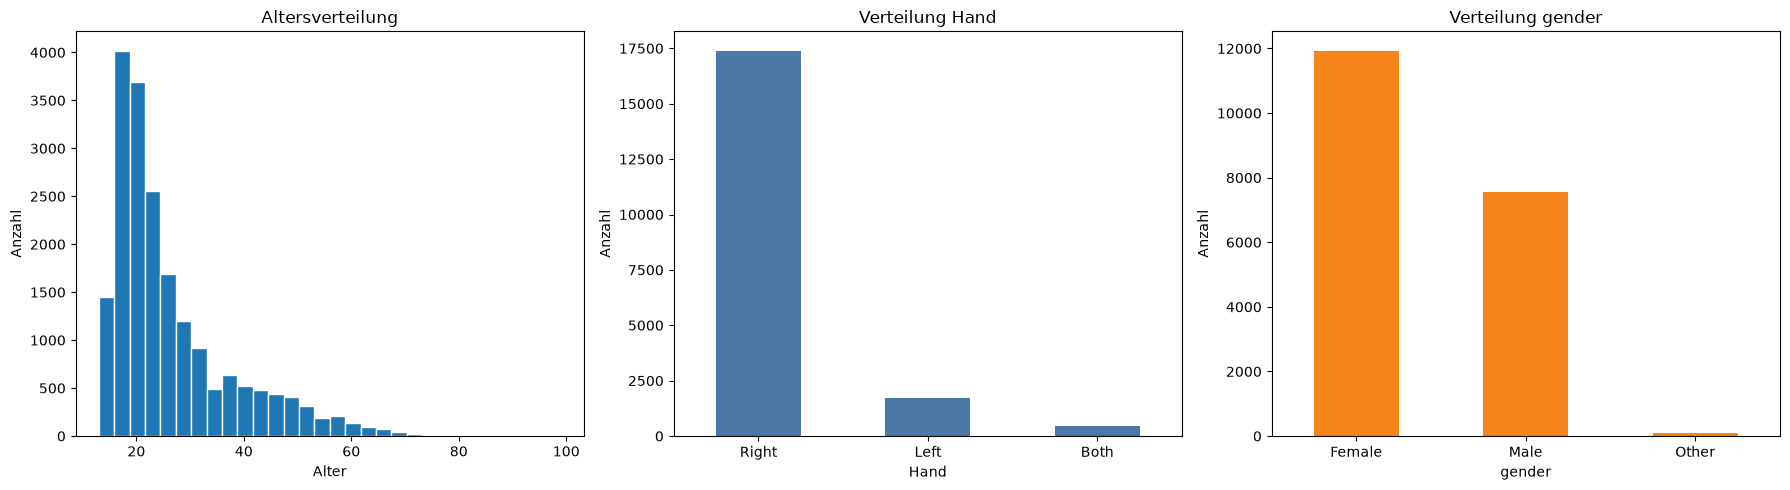

,age,gender,hand
count,19587.0,19587,19587
unique,<NA>,3,3
top,<NA>,Female,Right
freq,<NA>,11934,17398
mean,26.275489,NaN,NaN
std,11.538346,NaN,NaN
min,13.0,NaN,NaN
25%,18.0,NaN,NaN
50%,22.0,NaN,NaN
75%,31.0,NaN,NaN


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_clean['age'].dropna(), bins=30, edgecolor='white')
axes[0].set_title('Altersverteilung')
axes[0].set_xlabel('Alter')
axes[0].set_ylabel('Anzahl')

df_clean['hand'].value_counts().plot(kind='bar', ax=axes[1], color='#4C78A8')
axes[1].set_title('Verteilung Hand')
axes[1].set_xlabel('Hand')
axes[1].set_ylabel('Anzahl')
axes[1].tick_params(axis='x', rotation=0)

df_clean['gender'].value_counts().plot(kind='bar', ax=axes[2], color='#F58518')
axes[2].set_title('Verteilung gender')
axes[2].set_xlabel('gender')
axes[2].set_ylabel('Anzahl')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

display(df_clean[['age', 'gender', 'hand']].describe(include='all'))

Kurzinterpretation
Die Tabelle zum Datenverlust weist die Ausschlüsse in der festgelegten Reihenfolge aus. Dadurch wird jede Zeile nur einmal als entfernt gezählt. Die Übersicht der Prüfmasken davor zeigt zusätzlich, wie häufig einzelne Kriterien vor der Bereinigung auftreten und wie viele Zeilen mehrere Kriterien gleichzeitig erfüllen.
Die age-Spalte enthält nach der Bereinigung nur plausible Alterswerte. Umgerechnete Geburtsjahre sind als geschätzte Alter zu verstehen.